In [1]:
import scanpy as sc
import pandas as pd

import sys, os

import matplotlib.pyplot as plt
import palettable

from scipy.sparse import issparse
import numpy as np


In [2]:
import os, sys
os.chdir('../../data')
sys.path.append('../src')

In [3]:
os.chdir('../analysis')

d10_lapa_dz_clustered = sc.read_h5ad('cellassign_objects/d10_lapa_predictions.h5ad')

#### Print the metadata we filter one

In [4]:
d10_lapa_dz_clustered.obs

,orig.ident,nCount_RNA,nFeature_RNA,freemuxlet.identity,participant,Condition,Time_point,Treatment,ident,leiden,size_factor,initial_cellassign_prediction
AAACCAAAGGGTATGG-1,D10_Lapa,8249.0,3045,0,H896,G2D10_Lapa,G2D10,Lapa,D10_Lapa,2,0.889328,ISCs
AAACCAAAGGTTCAGC-1,D10_Lapa,5951.0,2426,0,H896,G2D10_Lapa,G2D10,Lapa,D10_Lapa,2,0.641580,ISCs
AAACCAAAGTAATGGA-1,D10_Lapa,6314.0,2901,1,H897,G2D10_Lapa,G2D10,Lapa,D10_Lapa,2,0.680715,ISCs
AAACCAAAGTCAGCAC-1,D10_Lapa,13571.0,4660,0,H896,G2D10_Lapa,G2D10,Lapa,D10_Lapa,6,1.463095,ISCs
AAACCAAAGTGCGCTG-1,D10_Lapa,5743.0,2694,0,H896,G2D10_Lapa,G2D10,Lapa,D10_Lapa,0,0.619155,ISCs
...,...,...,...,...,...,...,...,...,...,...,...,...
TGTGTTGAGGCGCTCA-1,D10_Lapa,7927.0,3290,0,H896,G2D10_Lapa,G2D10,Lapa,D10_Lapa,0,0.854613,ISCs
TGTGTTGAGGGTGAAT-1,D10_Lapa,12886.0,4452,2,H329,G2D10_Lapa,G2D10,Lapa,D10_Lapa,4,1.389245,Proliferating PCs
TGTGTTGAGTAGAGCG-1,D10_Lapa,6993.0,3144,0,H896,G2D10_Lapa,G2D10,Lapa,D10_Lapa,1,0.753918,ISCs
TGTGTTGAGTAGCGTC-1,D10_Lapa,6865.0,2951,2,H329,G2D10_Lapa,G2D10,Lapa,D10_Lapa,2,0.740119,ISCs


In [5]:
print(d10_lapa_dz_clustered.obs['initial_cellassign_prediction'])

AAACCAAAGGGTATGG-1                 ISCs
AAACCAAAGGTTCAGC-1                 ISCs
AAACCAAAGTAATGGA-1                 ISCs
AAACCAAAGTCAGCAC-1                 ISCs
AAACCAAAGTGCGCTG-1                 ISCs
                            ...        
TGTGTTGAGGCGCTCA-1                 ISCs
TGTGTTGAGGGTGAAT-1    Proliferating PCs
TGTGTTGAGTAGAGCG-1                 ISCs
TGTGTTGAGTAGCGTC-1                 ISCs
TGTGTTGAGTCGCGCA-1                 ISCs
Name: initial_cellassign_prediction, Length: 33507, dtype: category
Categories (7, object): ['EECs', 'Enterocytes', 'Goblet cells', 'ISCs', 'PCs', 'Proliferating PCs', 'Secretory PCs']


### Create a new object for our EEC cells

In [6]:
label_to_keep = ["EECs"]            # or ["3","7","9"]
metadata_key = "initial_cellassign_prediction"

mask = d10_lapa_dz_clustered.obs[metadata_key].isin(label_to_keep)
EECs_only = d10_lapa_dz_clustered[mask].copy() 

In [7]:
EECs_only

AnnData object with n_obs × n_vars = 819 × 28395
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident', 'leiden', 'size_factor', 'initial_cellassign_prediction'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'X_name', 'hvg', 'initial_cellassign_prediction_colors', 'leiden_colors'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

/opt/anaconda3/envs/single-cell-env/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:82: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)
/opt/anaconda3/envs/single-cell-env/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/opt/anaconda3/envs/single-cell-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/gs/k55rgtm50g938k87mvcdclqr0000gq/T/ipykernel_23110/2911989776.py:21: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc

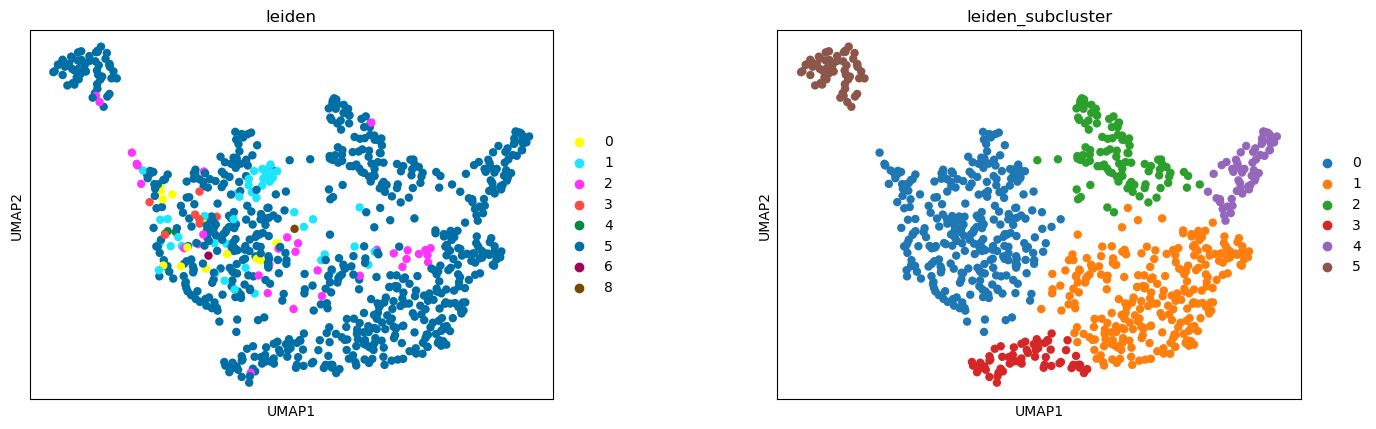

In [8]:
### Recluster

if "counts" in EECs_only.layers:
    EECs_only.X = EECs_only.layers["counts"].copy()
    sc.pp.filter_genes(EECs_only, min_counts=1)
    sc.pp.normalize_total(EECs_only, target_sum=1e4)
    sc.pp.log1p(EECs_only)

# Standard preprocessing
sc.pp.highly_variable_genes(EECs_only, n_top_genes=3000, flavor="seurat_v3")
adata_sub = EECs_only[:, EECs_only.var["highly_variable"]].copy()

sc.pp.scale(adata_sub, max_value=10)
sc.tl.pca(adata_sub, n_comps=50, svd_solver="arpack")

# Graph + UMAP
sc.pp.neighbors(adata_sub, n_neighbors=15, n_pcs=30)
sc.tl.umap(adata_sub)

# --- Recluster and save to a NEW slot ---
sc.tl.leiden(
    adata_sub,
    resolution=0.3,
    key_added="leiden_subcluster"   # <- new column in .obs
)

# (Nice-to-have) ensure string/categorical with clean ordering
adata_sub.obs["leiden_subcluster"] = (
    adata_sub.obs["leiden_subcluster"].astype(str).astype("category")
)

# Quick check
sc.pl.umap(adata_sub, color=["leiden", "leiden_subcluster"], wspace=0.3)

In [9]:
adata = adata_sub

#### Define the EEC hormones, for plotting

In [10]:
Enterochromaffin_markers = ["CHGA", "TPH1", "NEUROD1"]

Peptide_cell_markers = ["ARX", "MLN", "GHRL", "GIP", "CCK"]



EEC_marker_dictionary = {
    "Enterochromaffin_markers": ["CHGA", "TPH1", "NEUROD1"],
    "Peptide_cell_marker": ["ARX"],
    "M_cell_marker": ["MLN"],
    "X_cell_marker": ["GHRL"],
    "K_cell_marker": ["GIP"],
    "I_cell_marker": ["CCK"]

### TO DO; consider adding 'more' genes to this
}


#### Plot Enterochromaffin markers

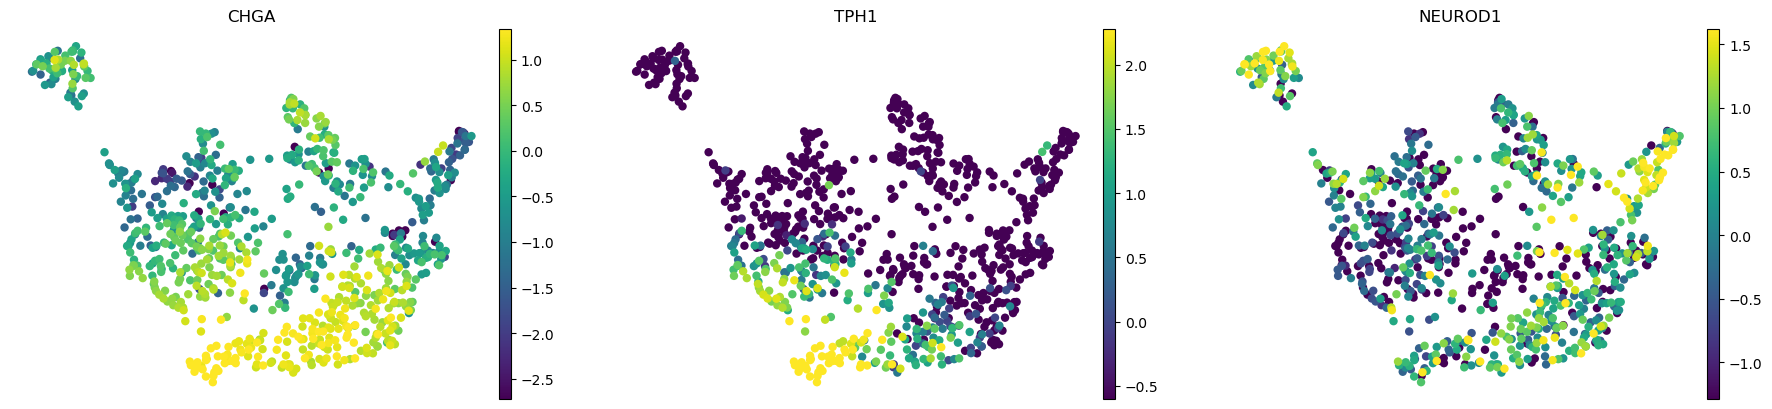

In [11]:
present = [g for g in Enterochromaffin_markers
           if (hasattr(adata, "raw") and adata.raw is not None and g in adata.raw.var_names) or
              (g in adata.var_names)]

sc.pl.umap(
    adata,
    color=present,
    ncols=4,          # show expression from .raw if you froze it
    vmax="p95",            # nicer dynamic range
    frameon=False
)

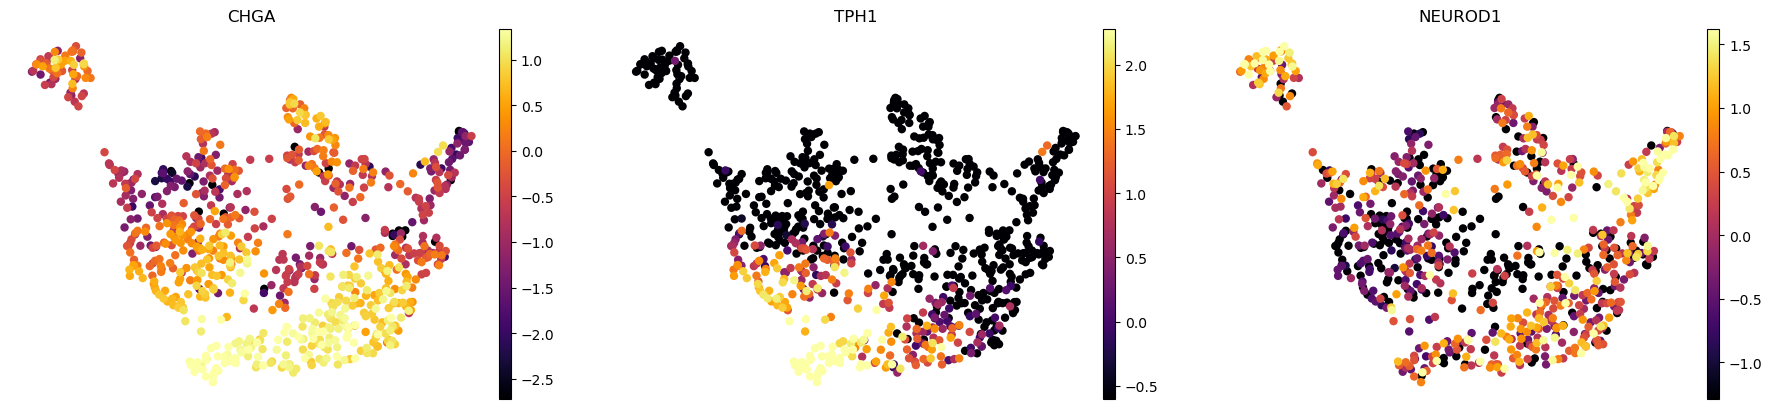

In [12]:
sc.pl.umap(
    adata,
    color=present,
    ncols=4,   
    cmap="inferno",# show expression from .raw if you froze it
    vmax="p95",            # nicer dynamic range
    frameon=False
)





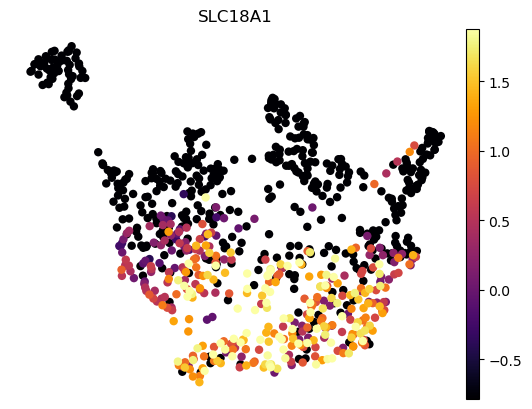

In [13]:
sc.pl.umap(
    adata,
    color="SLC18A1",
    ncols=4,   
    cmap="inferno",# show expression from .raw if you froze it
    vmax="p95",            # nicer dynamic range
    frameon=False
)





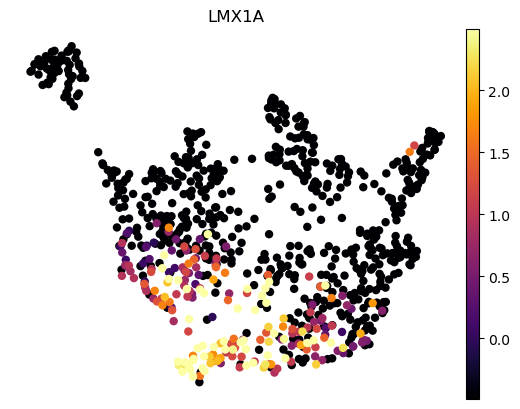

In [14]:
sc.pl.umap(
    adata,
    color="LMX1A",
    ncols=4,   
    cmap="inferno",# show expression from .raw if you froze it
    vmax="p95",            # nicer dynamic range
    frameon=False
)




#### Plot NEUROG3+ 

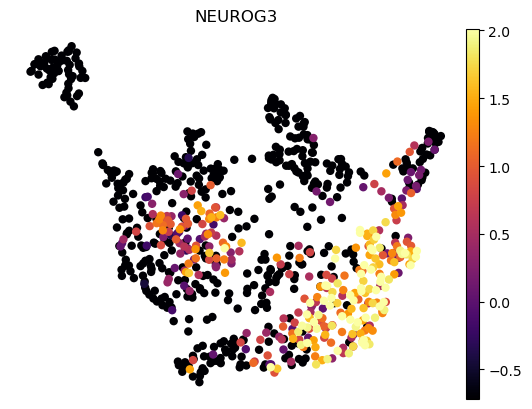

In [15]:
sc.pl.umap(
    adata,
    color="NEUROG3",
    ncols=4,          # show expression from .raw if you froze it
    vmax="p95", 
    cmap="inferno",         
    frameon=False
)

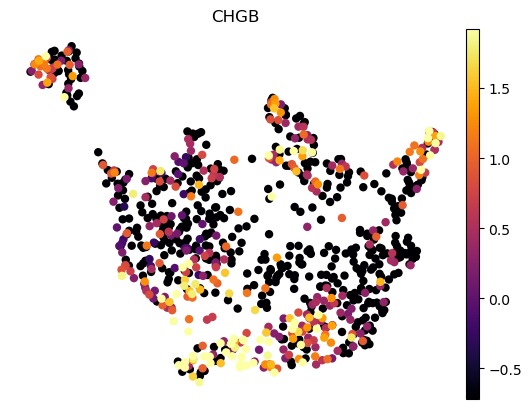

In [16]:
sc.pl.umap(
    adata,
    color="CHGB",
    ncols=4,          # show expression from .raw if you froze it
    vmax="p95", 
    cmap="inferno",         
    frameon=False
)

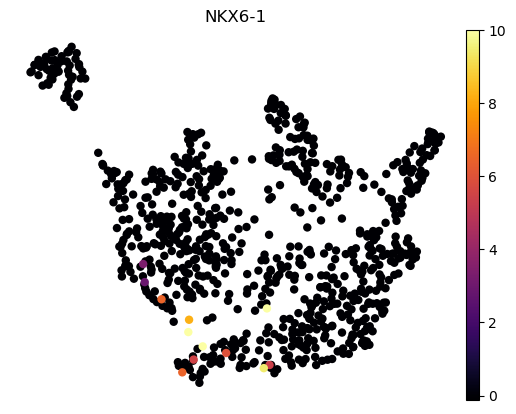

In [17]:
sc.pl.umap(
    adata,
    color="NKX6-1",
    ncols=4,          # show expression from .raw if you froze it
    cmap="inferno",         
    frameon=False
)

#### Plot peptide hormone markers

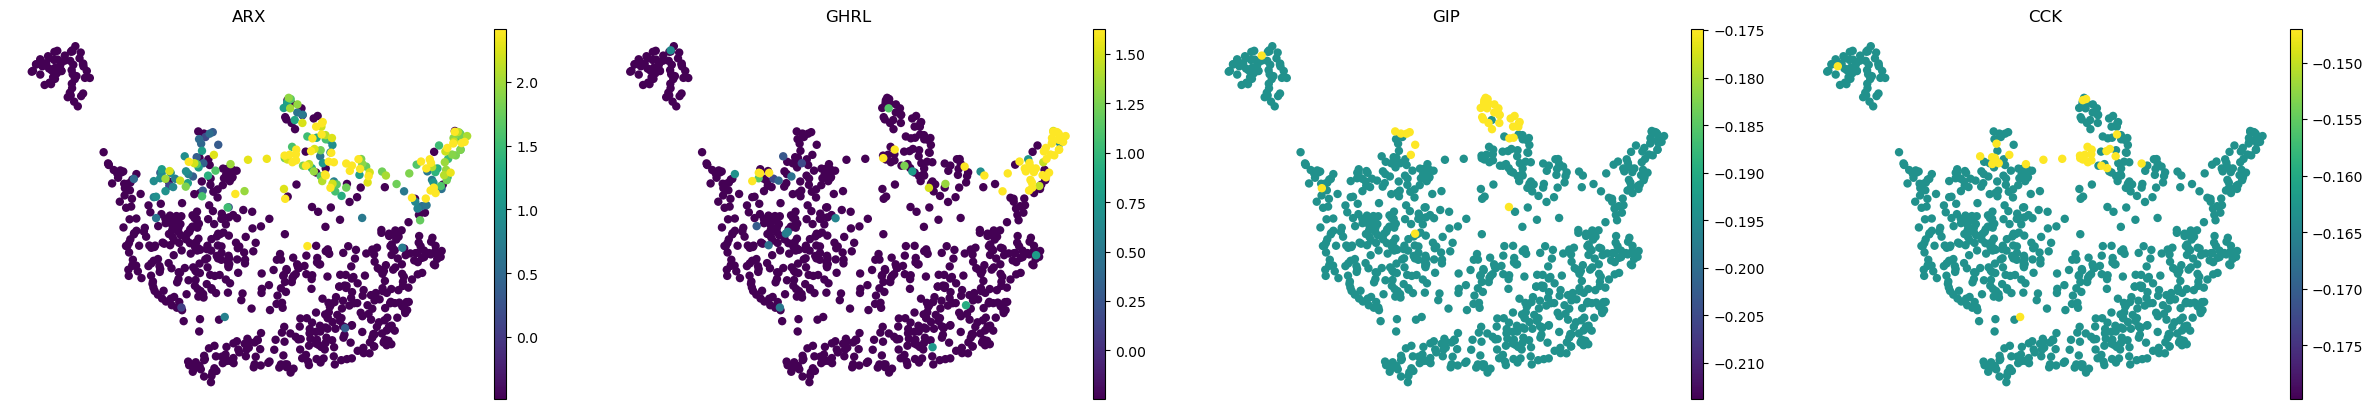

In [18]:
present = [g for g in Peptide_cell_markers
           if (hasattr(adata, "raw") and adata.raw is not None and g in adata.raw.var_names) or
              (g in adata.var_names)]

sc.pl.umap(
    adata,
    color=present,
    ncols=4,          # show expression from .raw if you froze it
    vmax="p95",            # nicer dynamic range
    frameon=False
)

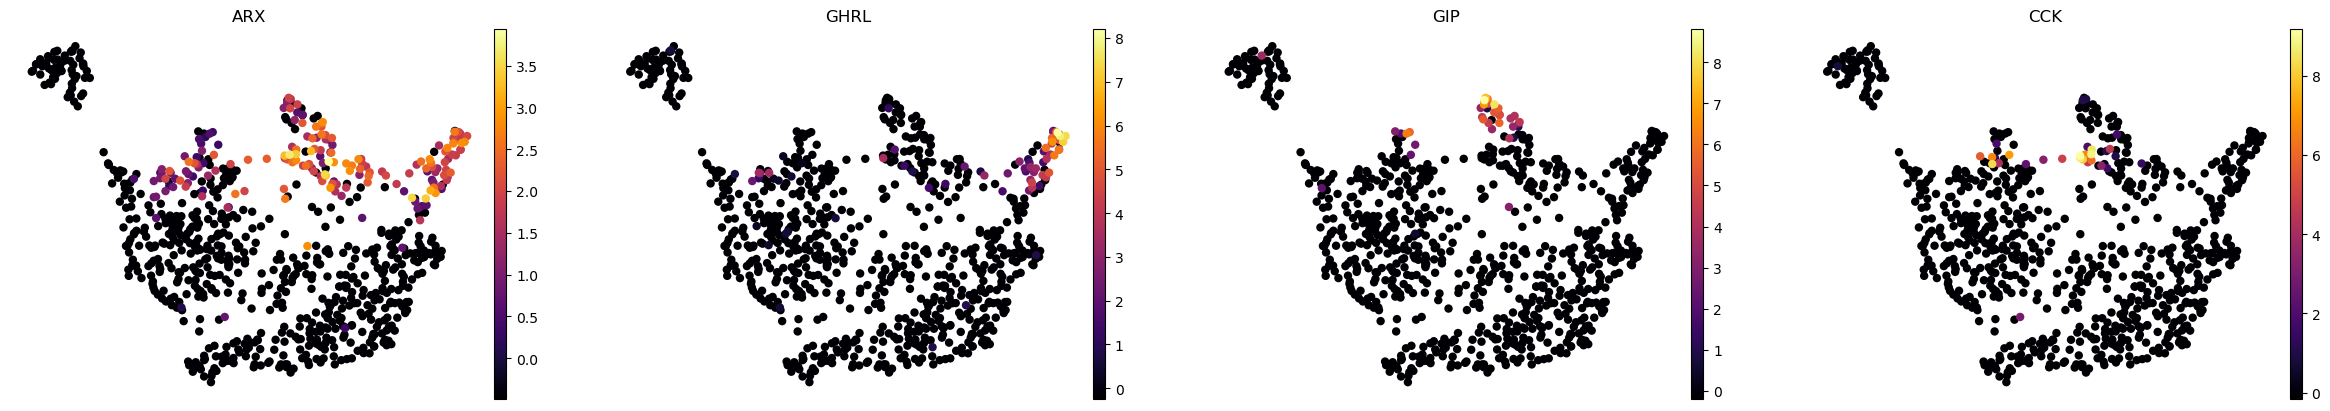

In [19]:
present = [g for g in Peptide_cell_markers
           if (hasattr(adata, "raw") and adata.raw is not None and g in adata.raw.var_names) or
              (g in adata.var_names)]

sc.pl.umap(
    adata,
    color=present,
    ncols=4, 
    cmap="inferno",         # show expression from .raw if you froze it
    frameon=False
)

#### Plot more peptide markers

In [20]:
More_Peptide_cell_markers = ["GCG", "PYY", "SST", "GAST", "NTS"]


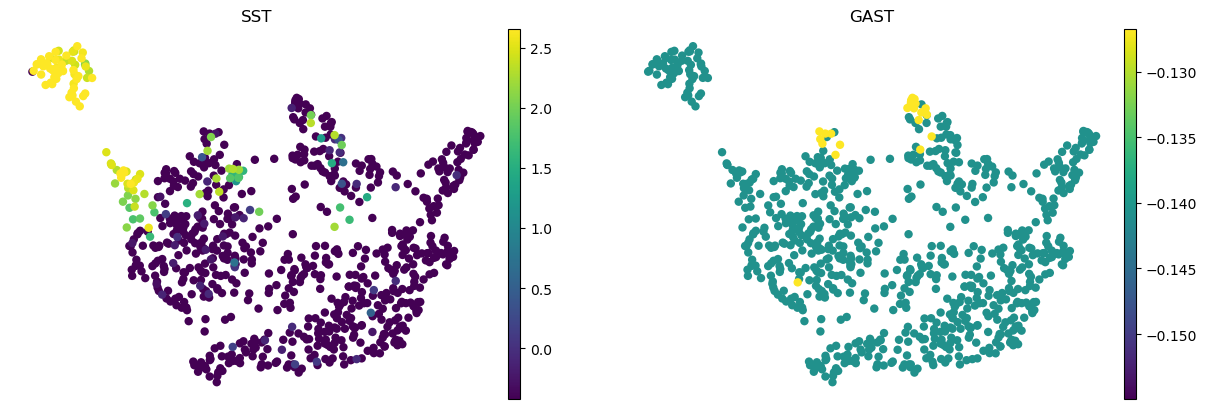

In [21]:
present = [g for g in More_Peptide_cell_markers
           if (hasattr(adata, "raw") and adata.raw is not None and g in adata.raw.var_names) or
              (g in adata.var_names)]

sc.pl.umap(
    adata,
    color=present,
    ncols=4,          # show expression from .raw if you froze it
    vmax="p95",            # nicer dynamic range
    frameon=False
)

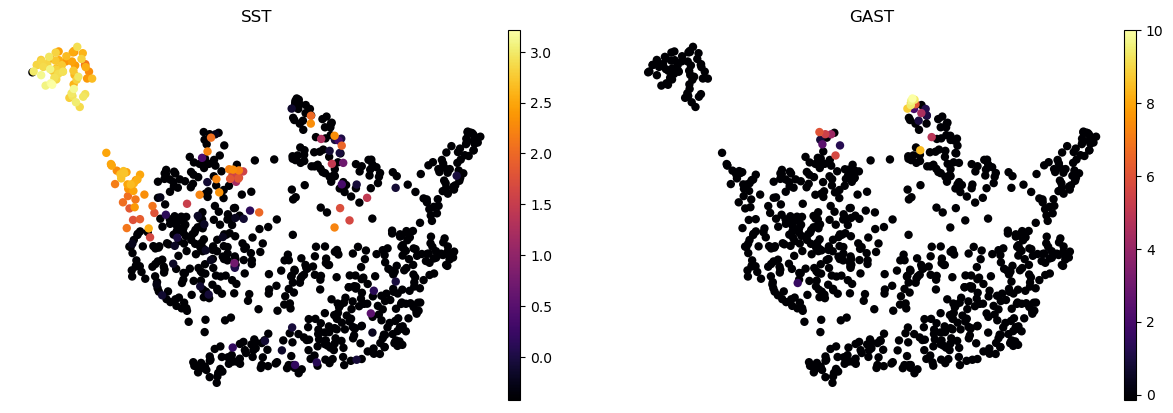

In [22]:

present = [g for g in More_Peptide_cell_markers
           if (hasattr(adata, "raw") and adata.raw is not None and g in adata.raw.var_names) or
              (g in adata.var_names)]

sc.pl.umap(
    adata,
    color=present,
    ncols=4,          # show expression from .raw if you froze it
    cmap="inferno",         
    frameon=False
)

#### Plot PAX4

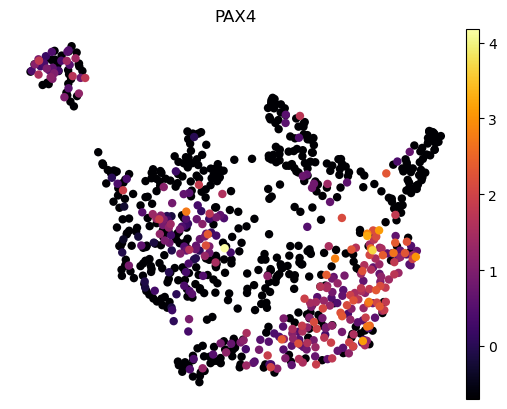

In [23]:
sc.pl.umap(
    adata,
    color="PAX4",
    ncols=4,          # show expression from .raw if you froze it
    cmap="inferno",         
    frameon=False
)

#### Plot PERCC1 & FAM181B

In [24]:
Cofactors = ["PERCC1", "FAM181B"]


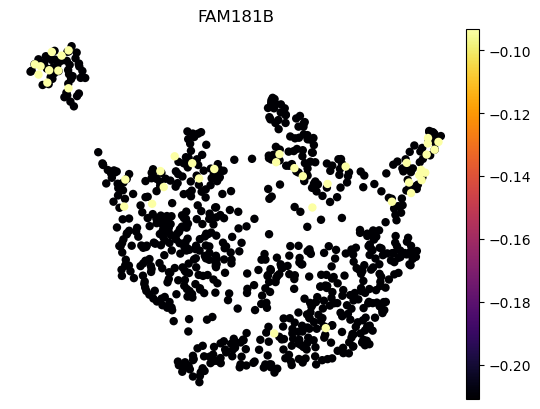

In [25]:
present = [g for g in Cofactors
           if (hasattr(adata, "raw") and adata.raw is not None and g in adata.raw.var_names) or
              (g in adata.var_names)]

sc.pl.umap(
    adata,
    color=present,
    ncols=4,          # show expression from .raw if you froze it
    vmax="p95", 
    cmap="inferno",         
    frameon=False
)

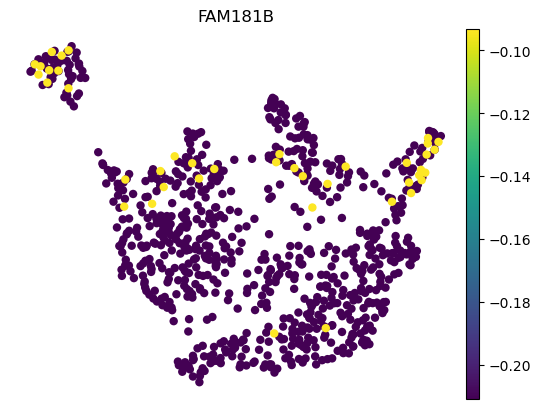

In [26]:
present = [g for g in Cofactors
           if (hasattr(adata, "raw") and adata.raw is not None and g in adata.raw.var_names) or
              (g in adata.var_names)]

sc.pl.umap(
    adata,
    color=present,
    ncols=4,          # show expression from .raw if you froze it
    vmax="p95",       
    frameon=False
)

#### Define the two new metadata slots for our labels of the EECs

In [27]:
adata.obs['EEC_label'] = adata.obs['initial_cellassign_prediction']
adata.obs['granular_EEC_label'] = adata.obs['initial_cellassign_prediction']


#### Define our function for filtering on gene expression

In [28]:

def gene_expr_bool(adata, gene, threshold=0.0):
    """
    Return a boolean array (n_cells,) indicating which cells express `gene`
    above `threshold` in adata.X.
    If the gene is missing, returns all False.
    """
    if gene not in adata.var_names:
        print(f"Warning: {gene} not found in var_names; treating as not expressed.")
        return np.zeros(adata.n_obs, dtype=bool)
    
    sub = adata[:, gene]
    X = sub.X
    if issparse(X):
        X = X.toarray()
    X = np.ravel(X)
    return X > threshold

#### Define the categories


In [29]:
# if it's categorical, add the new category values you want to assign
if pd.api.types.is_categorical_dtype(adata.obs["EEC_label"]):
    adata.obs["EEC_label"] = adata.obs["EEC_label"].cat.add_categories(
        ["Peptide-hormone EECs", "Enterochromaffin cells"]
    )

/var/folders/gs/k55rgtm50g938k87mvcdclqr0000gq/T/ipykernel_23110/2036105681.py:2: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(adata.obs["EEC_label"]):


#### Define the Peptide hormones cells

In [30]:
arx_pos = gene_expr_bool(adata, "ARX")
mask_peptide_eec = arx_pos
# Cells that are positive for SST should be included in this criteria 

sst_pos = gene_expr_bool(adata, "SST")
mask_peptide_eec = arx_pos | sst_pos


adata.obs.loc[mask_peptide_eec, "EEC_label"] = "Peptide-hormone EECs"






#### Remove the categories from the originally copied CellAssign metadata column


In [31]:

adata.obs["EEC_label"] = adata.obs["EEC_label"].cat.remove_unused_categories()


#### Define enterochromaffin cells as the remaining cells, based on the abundance of CHGA

In [32]:
adata.obs["EEC_label"] = np.where(
    mask_peptide_eec,
    "Peptide-hormone EECs",
    "Enterochromaffin cells"
)


#### Plot the result

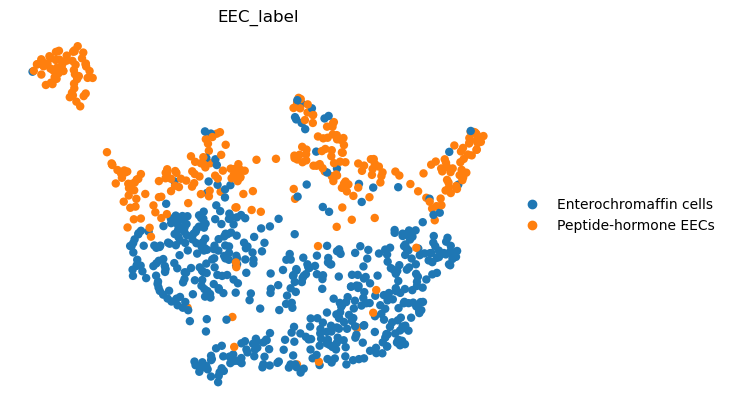

In [33]:
sc.pl.umap(
    adata,
    color="EEC_label",
    palette=sc.pl.palettes.default_20,  # or sc.pl.palettes.zeileis_28
    frameon=False
)

#### Repeat for the specific peptide cell types we've plotted

In [34]:
# if it's categorical, add the new category values you want to assign
if pd.api.types.is_categorical_dtype(adata.obs["granular_EEC_label"]):
    adata.obs["granular_EEC_label"] = adata.obs["granular_EEC_label"].cat.add_categories(
        ["X cells", "D cells", "I cells", "K cells", "Enterochromaffin cells", "ARX+ cells"]
    )

/var/folders/gs/k55rgtm50g938k87mvcdclqr0000gq/T/ipykernel_23110/1588881047.py:2: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(adata.obs["granular_EEC_label"]):


#### Define the ARX+ cells

In [36]:
arx_pos = gene_expr_bool(adata, "ARX")
mask_peptide_cell_eec = arx_pos
# Cells that are positive for SST should be included in this criteria 
adata.obs.loc[mask_peptide_cell_eec, "granular_EEC_label"] = "ARX+ cells"

#### Define the X cells

In [37]:
ghrl_pos = gene_expr_bool(adata, "GHRL")
mask_xcell_eec = ghrl_pos
# Cells that are positive for SST should be included in this criteria 
adata.obs.loc[mask_xcell_eec, "granular_EEC_label"] = "X cells"

#### Define the D cells

In [38]:
sst_pos = gene_expr_bool(adata, "SST")
mask_dcell_eec = sst_pos
# Cells that are positive for SST should be included in this criteria 
adata.obs.loc[mask_dcell_eec, "granular_EEC_label"] = "D cells"

#### Define the I cells

In [39]:
cck_pos = gene_expr_bool(adata, "CCK")
mask_icell_eec = cck_pos
# Cells that are positive for SST should be included in this criteria 
adata.obs.loc[mask_icell_eec, "granular_EEC_label"] = "I cells"

#### Define the K cells

In [40]:
gip_pos = gene_expr_bool(adata, "GIP")
mask_kcell_eec = gip_pos
# Cells that are positive for SST should be included in this criteria 
adata.obs.loc[mask_kcell_eec, "granular_EEC_label"] = "K cells"

#### Define the Enterochromaffin cells as the remaining cells

In [41]:

label_col = "granular_EEC_label"

# Ensure categorical + required categories exist
needed = ["X cells", "D cells", "I cells", "K cells", "ARX+ cells", "Enterochromaffin cells"]
if label_col not in adata.obs:
    adata.obs[label_col] = pd.Categorical([None] * adata.n_obs, categories=needed)
else:
    if not pd.api.types.is_categorical_dtype(adata.obs[label_col]):
        adata.obs[label_col] = adata.obs[label_col].astype("category")
    adata.obs[label_col] = adata.obs[label_col].cat.add_categories(
        [c for c in needed if c not in adata.obs[label_col].cat.categories]
    )

# Anything not already labeled as X/D/I/K becomes Enterochromaffin
assigned = adata.obs[label_col].isin(["X cells", "D cells", "I cells", "K cells", "ARX+ cells"])
adata.obs.loc[~assigned, label_col] = "Enterochromaffin cells"


/var/folders/gs/k55rgtm50g938k87mvcdclqr0000gq/T/ipykernel_23110/2179872091.py:8: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(adata.obs[label_col]):


In [42]:
#### Drop the unused labels

In [43]:
adata.obs["granular_EEC_label"] = adata.obs["granular_EEC_label"].cat.remove_unused_categories()


#### Plot the result

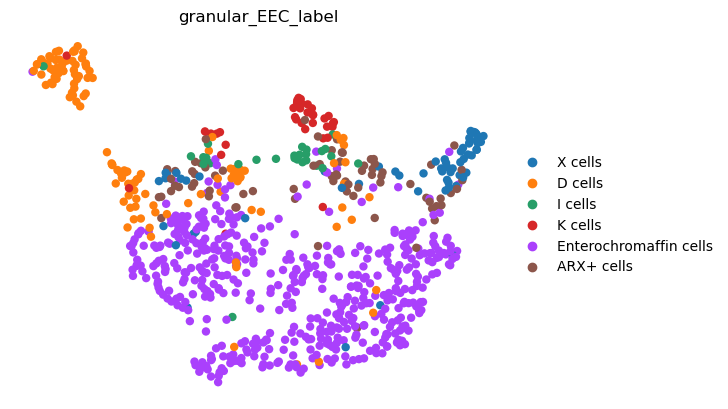

In [44]:
sc.pl.umap(
    adata,
    color="granular_EEC_label",
    palette=sc.pl.palettes.default_20,  # or sc.pl.palettes.zeileis_28
    frameon=False
)

In [45]:
adata

AnnData object with n_obs × n_vars = 819 × 3000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident', 'leiden', 'size_factor', 'initial_cellassign_prediction', 'leiden_subcluster', 'EEC_label', 'granular_EEC_label'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std', 'n_counts', 'highly_variable_rank', 'variances', 'variances_norm'
    uns: 'X_name', 'hvg', 'initial_cellassign_prediction_colors', 'leiden_colors', 'log1p', 'pca', 'neighbors', 'umap', 'leiden_subcluster', 'leiden_subcluster_colors', 'EEC_label_colors', 'granular_EEC_label_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [34]:
# --- Veres-style panel builder (Scanpy/AnnData) ---

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
import matplotlib.patheffects as PathEffects
from collections import Counter, OrderedDict
from sklearn.neighbors import NearestNeighbors
from palettable.colorbrewer.qualitative import Set1_9, Paired_10, Set2_8

# -------------------- typography to match paper --------------------
def setup_matplotlib_params():
    from matplotlib import rcParams
    rcParams['font.family'] = 'sans-serif'
    rcParams['font.sans-serif'] = ['Helvetica Neue', 'Arial', 'DejaVu Sans']
    rcParams['axes.titlesize'] = 5
    rcParams['axes.labelsize']  = 5
    rcParams['xtick.labelsize'] = 5
    rcParams['ytick.labelsize'] = 5
    rcParams['axes.linewidth']  = 0.5
    rcParams['xtick.major.width'] = 0.5
    rcParams['ytick.major.width'] = 0.5
    rcParams['pdf.fonttype'] = 42  # editable text in Illustrator

setup_matplotlib_params()

# -------------------- core color registry (as in figure_vis.py) --------------------
def _col(x): return np.array(x)/255.

class CoreColors:
    def __init__(self):
        base = dict(zip(
            ['red','blue','green','purple','orange','yellow','brown','pink','grey'],
            Set1_9.colors
        ))
        for k,v in base.items(): setattr(self, k, _col(v))
        for name,c in zip(['blue','green','red','orange','purple'], Paired_10.colors[::2]):
            setattr(self, 'pale_'+name, _col(c))
        self.teal        = _col(Set2_8.colors[0])
        self.pale_brown  = _col([193,128,108])
        self.light_grey  = _col(Set2_8.colors[-1])
        self.dark_green  = _col([52,117,50])
        self.dark_grey   = np.array([0.5,0.5,0.5])

core_colors = CoreColors()

# -------------------- label params (you can fully customize) --------------------
def make_label_params(category_names):
    """
    Build a label->dict(color, short_label) map deterministically from the
    Veres palettes. Edit this to hard-code exact colors if desired.
    """
    palette = (
        Set1_9.colors + Paired_10.colors[::2] + Set2_8.colors
    )
    lp = OrderedDict()
    for name, col in zip(category_names, palette):
        lp[name] = dict(color=_col(col), short_label=name)
    return lp

# -------------------- identical logic: sort to put homogeneous neighborhoods on top --------------------
def prepare_for_scatter(X, labels, label_params):
    labels = np.asarray(labels)
    nbrs = NearestNeighbors(n_neighbors=10, algorithm='ball_tree').fit(X)
    knn = nbrs.kneighbors(X, return_distance=False)
    # fraction of neighbors with the same label; sort so dense/consistent are on top
    same = (labels[knn].T == labels[knn][:,0].T).mean(0)
    order = np.argsort(same)
    # map labels -> RGB
    colors = np.ones((len(labels),3))*0.5
    for k,v in label_params.items():
        colors[labels==k] = v['color']
    return X[order], colors[order]

# -------------------- the panel function (ports the notebook code) --------------------
def plot_veres_panel(
    adata,
    label_key,                 # e.g. "initial_cellassign_prediction_colors"
    stage_text=None,           # e.g. "D10_Lapa"
    ratio_order=None,          # list specifying order in pop-bar (optional)
    label_order=None,          # legend order (optional)
    save=None,                 # path to .pdf/.png
    dpi=600
):
    # coords & labels
    X = adata.obsm['X_umap']
    labels = adata.obs[label_key].astype(str).values
    cats = list(pd.unique(labels)) if label_order is None else label_order

    # label params (color + short label)
    lp = make_label_params(cats)

    # ===== panel sizing exactly like their notebook =====
    mm_per_inch = 25.4
    panel_size_in = ((89/2)/mm_per_inch, 25.4/mm_per_inch)  # (W, H)
    cell_pop_bar_h = 0.07
    heights = ((1 - cell_pop_bar_h)*panel_size_in[1], cell_pop_bar_h*panel_size_in[1])
    widths  = (panel_size_in[0] - heights[0], heights[0])  # legend column narrower than scatter

    fig = plt.figure(figsize=panel_size_in, dpi=dpi)
    gs  = gridspec.GridSpec(2, 2, fig, 0,0,1,1,
                            hspace=0, wspace=0,
                            width_ratios=widths, height_ratios=heights)

    # ===== left column: title + legend (with colored dots) =====
    ax = fig.add_subplot(gs[0,0], xticks=[], yticks=[], xlim=[0,1], ylim=[0,1], frameon=False)
    li = 1
    yl = lambda i: 1 - i/10.5
    xl_dot, xl_head, xl_text = 0.22, 0.30, 0.30

    # Title ("Stage X" in Veres; we show stage_text and n_cells)
    if stage_text is None:
        stage_text = ""
    ax.text(xl_head, yl(li) + 0.1, f"{stage_text}", va='center', fontsize=6, fontweight='extra bold', clip_on=False) ### changed line
    li += 1
    ax.text(xl_head, yl(li), f"({adata.n_obs:,} cells)", va='center', fontsize=5, clip_on=False)
    li += 1.5

    present = [c for c in (label_order or cats) if c in set(labels)]
    for lb in present:
        lb_txt = lp[lb]['short_label']
        ax.scatter(xl_dot, yl(li)+0.008, s=15, c=lp[lb]['color'].reshape(1,-1), clip_on=False)
        for line in str(lb_txt).splitlines():
            ax.text(xl_text, yl(li), line, va='center', fontsize=5, clip_on=False)
            li += 1

    # ===== right column: layered scatter (black -> white -> color), alpha as in notebook =====
    proj, rgb = prepare_for_scatter(X, labels, lp)
    ax = fig.add_subplot(gs[0,1], xticks=[], yticks=[], frameon=False, zorder=-1)
    ax.patch.set_visible(False)

    s_black, s_white, s_type = 4, 2, 1.5   # EXACT dot sizes used in the notebook
    ax.scatter(proj[:,0], proj[:,1], c='k', edgecolor='none', s=s_black, rasterized=True)
    ax.scatter(proj[:,0], proj[:,1], c='w', edgecolor='none', s=s_white, rasterized=True)
    ax.scatter(proj[:,0], proj[:,1], c=rgb, edgecolor='none', s=s_type, alpha=0.7, rasterized=True)

    # ===== bottom row: population ratio bar (with border rectangle and label) =====
    ax = fig.add_subplot(gs[1,0:2], xticks=[], yticks=[], xlim=[0,1], ylim=[0,1], frameon=False)

    counts = pd.Series(Counter(labels))
    fracs  = counts / counts.sum()
    rr = ratio_order or present  # if no ratio_order, follow legend order

    cumul = 0.0
    for lb in rr:
        if lb in fracs:
            w = float(fracs[lb])
            ax.add_patch(patches.Rectangle((0.30 + 0.68*cumul, 0.02), 0.68*w, 1.0,
                                           facecolor=lp[lb]['color'], edgecolor='none', clip_on=False))
            cumul += w

    ax.text(0.175, 0.5, 'Pop. ratios:', va='center', ha='center', fontsize=5, clip_on=False)
    ax.add_patch(patches.Rectangle((0.30, 0.02), 0.68, 1.0, facecolor='none', edgecolor='k', linewidth=0.5, clip_on=False))

    plt.tight_layout()
    if save:
        fig.savefig(save, dpi=dpi, transparent=True, bbox_inches='tight')
    return fig


/var/folders/gs/k55rgtm50g938k87mvcdclqr0000gq/T/ipykernel_26526/170953578.py:156: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


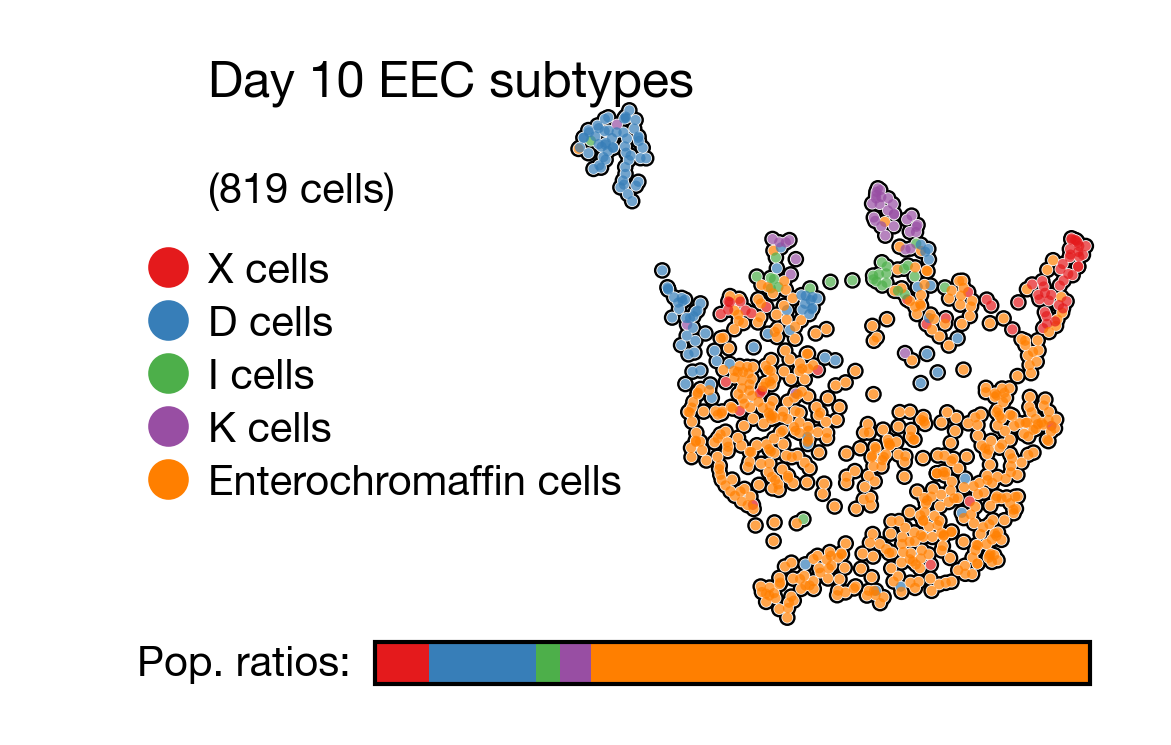

In [35]:
# Your schema
STAGE = "D10_Lapa"
LABEL_KEY = "granular_EEC_label"  # or your final label column

# Optional: lock display order (legend + pop-bar) to your preferred sequence
label_order = [
    "X cells", "D cells", "I cells",
    "K cells", "Enterochromaffin cells"
]
ratio_order = label_order  # can be different if you wish

# Subset if you had multiple stages; otherwise just pass your AnnData
fig = plot_veres_panel(
    adata, 
    label_key=LABEL_KEY,
    stage_text="Day 10 EEC subtypes",
    label_order=label_order,   # or None to use dataset order
    ratio_order=ratio_order,   # or None
    save="D10_EEC_subtypes.pdf"
)


#### Plotting our custom image for the simple EC peptide hormone bifurcation

/var/folders/gs/k55rgtm50g938k87mvcdclqr0000gq/T/ipykernel_26526/170953578.py:156: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


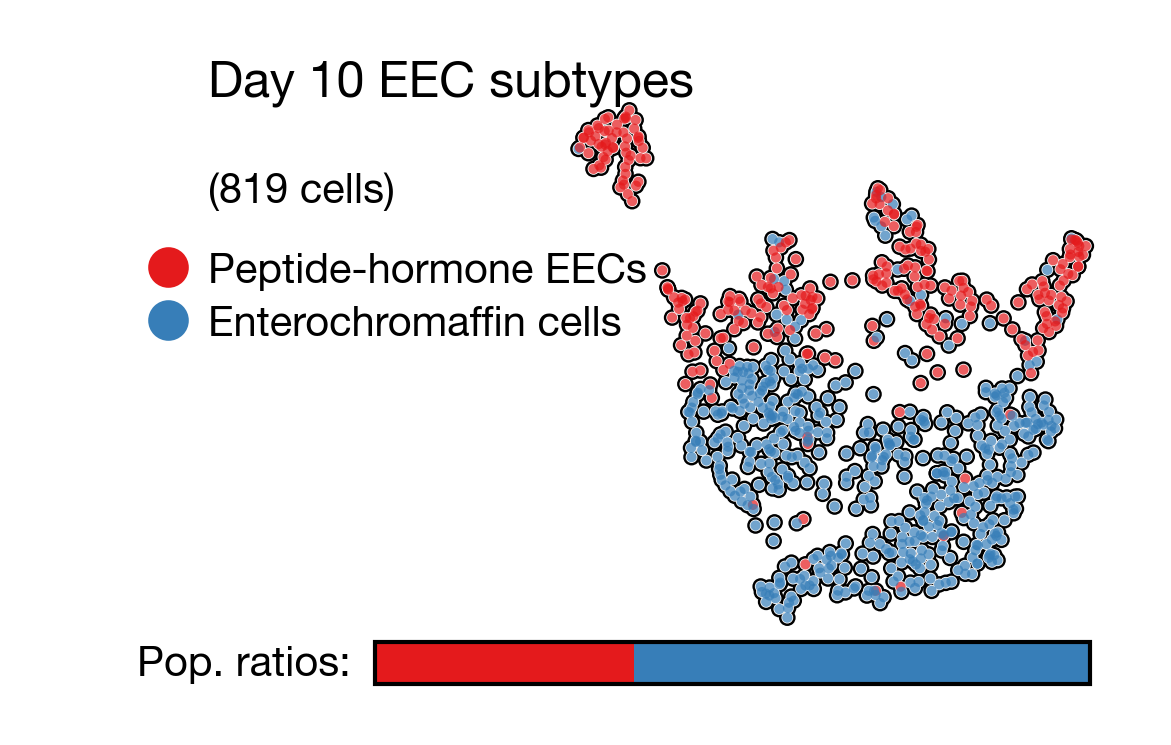

In [37]:
# Your schema
STAGE = "D10_Lapa"
LABEL_KEY = "EEC_label"  # or your final label column

# Optional: lock display order (legend + pop-bar) to your preferred sequence
label_order = [
    "Peptide-hormone EECs",
    "Enterochromaffin cells"
]
ratio_order = label_order  # can be different if you wish

# Subset if you had multiple stages; otherwise just pass your AnnData
fig = plot_veres_panel(
    adata, 
    label_key=LABEL_KEY,
    stage_text="Day 10 EEC subtypes",
    label_order=label_order,   # or None to use dataset order
    ratio_order=ratio_order,   # or None
    save="D10_simple_EEC_subtypes.pdf"
)


#### Save our new object

In [38]:
intermediate_directory = '/Users/stanleydale/user_generated/breault-lab/single-cell/analysis/manual_labelled_2'
sc.write(f'{intermediate_directory}/subclustered_EECs_egfDuod_D10_Lapa_DZ.h5ad', adata)